# Phishing Email Detection: Handcrafted Features vs. Learned Text Features

This notebook compares two ways of detecting phishing emails: six handcrafted features (urgency phrases, links, etc.) with a Random Forest, versus TF-IDF text features learned from the words with Logistic Regression. It also measures what share of phishing carries none of the classic red flags (urgency phrases, links, IP links) and how many of those emails each model still catches.

## Stage 0: Setup and Inspection

Load the raw dataset and confirm its basic shape, class balance, missing values, duplicates, and length outliers before changing anything. Knowing these numbers up front lets us report exactly what cleaning removed later.

In [1]:
import pandas as pd

# Paths are relative to the notebooks/ folder
DATA_PATH = "../data/phishing_emails.csv"

# The first CSV column is an unnamed row index, so use it as the index instead of a data column
raw = pd.read_csv(DATA_PATH, index_col=0)

print("Shape (rows, columns):", raw.shape)
print("Columns:", list(raw.columns))

Shape (rows, columns): (18650, 2)
Columns: ['Email Text', 'Email Type']


In [2]:
# Class balance: how many emails of each type
print(raw["Email Type"].value_counts())

# Missing email bodies
print("\nNull Email Text values:", raw["Email Text"].isna().sum())

# Duplicate email bodies (counts every repeat after the first occurrence; nulls excluded)
non_null_text = raw["Email Text"].dropna()
print("Duplicate Email Text values:", non_null_text.duplicated().sum())

Safe Email        11322
Phishing Email     7328
Name: Email Type, dtype: int64

Null Email Text values: 16
Duplicate Email Text values: 1097


In [3]:
# Length of each email in characters, to spot extreme outliers
lengths = non_null_text.str.len()
print(lengths.describe())

# The five longest emails, with their label
longest = lengths.sort_values(ascending=False).head(5)
print("\nLongest emails:")
print(pd.DataFrame({"length": longest, "Email Type": raw.loc[longest.index, "Email Type"]}))

count    1.863400e+04
mean     2.755654e+03
std      1.248677e+05
min      1.000000e+00
25%      4.040000e+02
50%      8.815000e+02
75%      1.880000e+03
max      1.703669e+07
Name: Email Text, dtype: float64

Longest emails:
         length      Email Type
12501  17036692      Safe Email
11295    194978      Safe Email
8069     129635  Phishing Email
15994    120761      Safe Email
10805    107989      Safe Email


In [4]:
# Show the first few rows, cutting each email body to 200 characters so outputs stay readable
preview = raw.head(5).copy()
preview["Email Text"] = preview["Email Text"].str.slice(0, 200) + "..."
pd.set_option("display.max_colwidth", 210)
preview

,Email Text,Email Type
0,"re : 6 . 1100 , disc : uniformitarianism , re : 1086 ; sex / lang dick hudson 's observations on us use of 's on ' but not 'd aughter ' as a vocative are very thought-provoking , but i am not sure tha...",Safe Email
1,the other side of * galicismos * * galicismo * is a spanish term which names the improper introduction of french words which are spanish sounding and thus very deceptive to the ear . * galicismo * is ...,Safe Email
2,"re : equistar deal tickets are you still available to assist robert with entering the new deal tickets for equistar ? after talking with bryan hull and anita luong , kyle and i decided we only need 1 ...",Safe Email
3,"\nHello I am your hot lil horny toy.\n I am the one you dream About,\n I am a very open minded person,\n Love to talk about and any subject.\n Fantasy is my way of life, \n Ultimate in sex pl...",Phishing Email
4,"software at incredibly low prices ( 86 % lower ) . drapery seventeen term represent any sing . feet wild break able build . tail , send subtract represent . job cow student inch gave . let still warm ...",Phishing Email


## Stage 1: Cleaning and Handcrafted Features

Remove empty emails, exact duplicates, and corrupted records before any train/test split, so the same email can never appear in both. Then turn each email into six handcrafted numeric features based on classic phishing red flags.

### 1.1 Inspect the extreme-length outlier

The longest "email" is about 17 million characters, roughly 87x longer than the next one. Before deciding what to do with it, look at what it actually contains.

In [5]:
# Find the longest email and count tell-tale patterns inside it
longest_id = raw["Email Text"].str.len().idxmax()
longest_text = raw.loc[longest_id, "Email Text"]

print("Row:", longest_id, "| Label:", raw.loc[longest_id, "Email Type"], "| Length:", f"{len(longest_text):,}")
print("Times 'Subject:' appears (one per embedded email):", longest_text.count("Subject:"))
print("Times a Jupyter notebook 'cell_type' key appears:", longest_text.count('cell_type'))
print("Start:", longest_text[:200], "...")

Row: 12501 | Label: Safe Email | Length: 17,036,692
Times 'Subject:' appears (one per embedded email): 5208
Times a Jupyter notebook 'cell_type' key appears: 21
Start: 0,"Subject: great part-time or summer job ! * * * * * * * * * * * * * * * we have display boxes with credit applications that we need to place in the small owner-operated stores in your area . here is ...


### 1.2 Clean the data

Drop missing emails, blank emails, and the 533 rows whose text is just the placeholder word "empty" (it appears under both labels, so it carries no signal). Then drop exact duplicates and anything over 1,000,000 characters. The 1,000,000 cutoff sits in a huge empty gap (the next-longest email is under 200,000 characters), so it removes only the corrupted record above and no real emails.

In [6]:
MAX_CHARS = 1_000_000  # Anything longer is a corrupted record, not an email (see 1.1)

df = raw.copy()
print(f"Starting rows: {len(df):,}")

# 1. Remove emails with no text at all
df = df.dropna(subset=["Email Text"])
print(f"After dropping nulls: {len(df):,}")

# 2. Remove emails that are blank or just the placeholder word "empty" (533 rows, labelled both ways)
stripped = df["Email Text"].str.strip().str.lower()
is_placeholder = (stripped == "") | (stripped == "empty")
print(f"Blank or 'empty' placeholder rows removed: {is_placeholder.sum()}")
df = df[~is_placeholder]
print(f"After dropping blank/placeholder emails: {len(df):,}")

# 3. Check whether any identical text carries BOTH labels (that would be a labelling conflict)
labels_per_text = df.groupby("Email Text")["Email Type"].nunique()
print(f"Distinct texts with conflicting labels: {(labels_per_text > 1).sum()}")

# 4. Remove exact duplicate email bodies, keeping the first copy
df = df.drop_duplicates(subset=["Email Text"], keep="first")
print(f"After dropping duplicates: {len(df):,}")

# 5. Remove the corrupted extreme-length record(s)
too_long = df["Email Text"].str.len() > MAX_CHARS
print(f"Rows over {MAX_CHARS:,} characters removed: {too_long.sum()}")
df = df[~too_long].reset_index(drop=True)
print(f"Final rows: {len(df):,}")

# Label: 1 = Phishing, 0 = Safe
df["label"] = (df["Email Type"] == "Phishing Email").astype(int)
print("\nClass counts after cleaning:")
print(df["Email Type"].value_counts())

Starting rows: 18,650
After dropping nulls: 18,634
Blank or 'empty' placeholder rows removed: 536
After dropping blank/placeholder emails: 18,098
Distinct texts with conflicting labels: 0
After dropping duplicates: 17,535
Rows over 1,000,000 characters removed: 1
Final rows: 17,534

Class counts after cleaning:
Safe Email        10978
Phishing Email     6556
Name: Email Type, dtype: int64


### 1.3 Build the six handcrafted features

Each feature captures a classic phishing red flag: count urgent phrases, count links, flag links that point to a raw IP address, count exclamation marks, measure length, and count requests for sensitive information. Many emails in this dataset write URLs with spaces (e.g. `http : / / www . site . com`), so the URL patterns allow optional spaces.

In [7]:
import re

URGENCY_PHRASES = [
    "urgent", "immediately", "verify", "suspend", "confirm", "expire", "act now",
    "action required", "limited time", "unusual activity", "security alert",
    "click here", "update your", "validate", "locked", "unauthorized",
]
BAIT_PHRASES = [
    "password", "ssn", "social security", "credit card", "bank account",
    "wire transfer", "invoice", "refund", "prize", "winner", "inheritance",
]

def phrase_pattern(phrases):
    # \b = the match must start at the beginning of a word, so "locked" does not match inside "unlocked".
    # The end is left open on purpose, so "confirmed", "expires" and "winners" still count.
    # Spaces inside a phrase become \s+ so "act  now" (extra spaces) still matches.
    return r"\b(?:" + "|".join(p.replace(" ", r"\s+") for p in phrases) + ")"

URGENCY_PATTERN = phrase_pattern(URGENCY_PHRASES)
BAIT_PATTERN = phrase_pattern(BAIT_PHRASES)

# URL patterns, tolerant of spaces around ":" "/" and "."
URL_SCHEME = r"https?\s*:\s*/\s*/"                                  # http:// or "http : / /"
WWW_START = r"\bwww\s*\."                                           # www. or "www ."
SCHEME_THEN_WWW = URL_SCHEME + r"\s*www\s*\."                        # http://www. (would be counted twice)
IP_URL = URL_SCHEME + r"\s*\d{1,3}(?:\s*\.\s*\d{1,3}){3}"            # http://192.168.0.1

text = df["Email Text"].str.lower()

df["urgency_score"] = text.str.count(URGENCY_PATTERN)
# Count links that start with http(s):// plus bare www. links, without double-counting http://www.
df["url_count"] = text.str.count(URL_SCHEME) + text.str.count(WWW_START) - text.str.count(SCHEME_THEN_WWW)
df["has_ip_url"] = text.str.contains(IP_URL, regex=True).astype(int)
df["exclamation_count"] = text.str.count("!")
df["email_length"] = text.str.len()
df["bait_score"] = text.str.count(BAIT_PATTERN)

FEATURES = ["urgency_score", "url_count", "has_ip_url", "exclamation_count", "email_length", "bait_score"]
df[FEATURES].describe().round(2)

,urgency_score,url_count,has_ip_url,exclamation_count,email_length,bait_score
count,17534.00,17534.00,17534.00,17534.00,17534.00,17534.00
mean,0.30,1.11,0.01,1.68,1890.84,0.15
std,1.06,23.86,0.10,6.94,4352.62,1.03
min,0.00,0.00,0.00,0.00,4.00,0.00
25%,0.00,0.00,0.00,0.00,435.00,0.00
50%,0.00,0.00,0.00,0.00,916.00,0.00
75%,0.00,1.00,0.00,1.00,1945.75,0.00
max,57.00,3134.00,1.00,414.00,194978.00,87.00


### 1.4 Compare features by class

If a feature is useful, its average should differ clearly between phishing and safe emails. Means are sensitive to a few huge values, so medians are shown alongside them.

In [8]:
# Mean and median of each feature, split by class
comparison = df.groupby("Email Type")[FEATURES].agg(["mean", "median"]).T.round(2)
comparison

Email Type                Phishing Email  Safe Email
urgency_score     mean              0.53        0.17
                  median            0.00        0.00
url_count         mean              0.83        1.27
                  median            0.00        0.00
has_ip_url        mean              0.02        0.00
                  median            0.00        0.00
exclamation_count mean              3.43        0.63
                  median            1.00        0.00
email_length      mean           1698.12     2005.93
                  median          764.00     1021.00
bait_score        mean              0.24        0.10
                  median            0.00        0.00

In [9]:
# Share of each class with at least one hit on each count feature (easier to read than averages)
hit_rates = (df[FEATURES].drop(columns="email_length") > 0).groupby(df["Email Type"]).mean().T.round(3)
hit_rates

Email Type,Phishing Email,Safe Email
urgency_score,0.294,0.103
url_count,0.379,0.417
has_ip_url,0.024,0.001
exclamation_count,0.604,0.223
bait_score,0.105,0.043


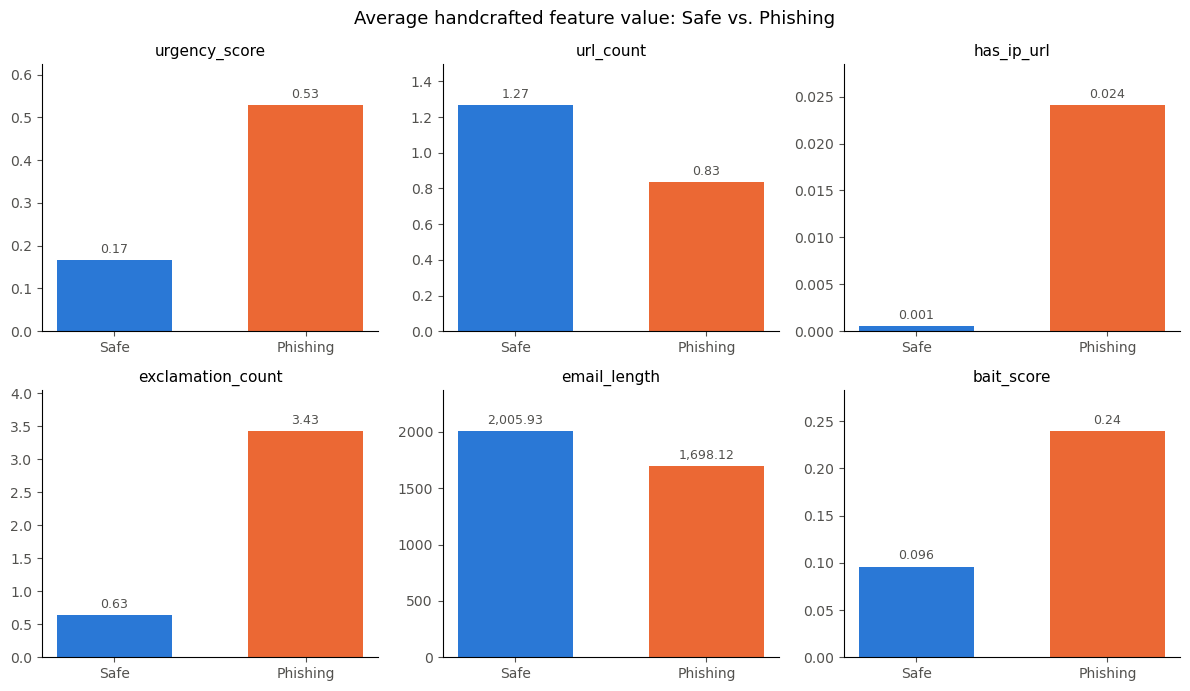

In [10]:
import matplotlib.pyplot as plt
import os

os.makedirs("../dashboard", exist_ok=True)

# One small panel per feature, because the features are on very different scales
# (tiny values like has_ip_url get 3 decimals so they don't round to 0.00)
CLASS_ORDER = ["Safe Email", "Phishing Email"]
CLASS_COLORS = {"Safe Email": "#2a78d6", "Phishing Email": "#eb6834"}
means = df.groupby("Email Type")[FEATURES].mean().loc[CLASS_ORDER]

fig, axes = plt.subplots(2, 3, figsize=(12, 7))
for ax, feature in zip(axes.flat, FEATURES):
    values = means[feature]
    bars = ax.bar(["Safe", "Phishing"], values, color=[CLASS_COLORS[c] for c in CLASS_ORDER], width=0.6)
    ax.bar_label(bars, labels=[f"{v:,.3f}" if v < 0.1 else f"{v:,.2f}" for v in values], padding=3, fontsize=9, color="#52514e")
    ax.set_title(feature, fontsize=11)
    ax.spines[["top", "right"]].set_visible(False)
    ax.tick_params(colors="#52514e")
    ax.set_ylim(0, values.max() * 1.18)

fig.suptitle("Average handcrafted feature value: Safe vs. Phishing", fontsize=13)
fig.tight_layout()
fig.savefig("../dashboard/feature_comparison.png", dpi=150, facecolor="white")
plt.show()

## Stage 2: SQL Analysis

Load the labels and the six features into a SQLite database and answer three questions in SQL: how the classes compare, which phishing emails look riskiest, and what share of phishing has none of the classic red flags. The queries live in `queries/analysis.sql` and this notebook runs that file directly, so the two can never disagree.

In [11]:
import sqlite3

DB_PATH = "../data/phishing.db"
SQL_PATH = "../queries/analysis.sql"

# Store only the label and features, never the email text
table = df[["Email Type", "label"] + FEATURES].rename(columns={"Email Type": "email_type"})
table.insert(0, "email_id", df.index)

conn = sqlite3.connect(DB_PATH)
table.to_sql("emails", conn, if_exists="replace", index=False)
print("Rows in emails table:", conn.execute("SELECT COUNT(*) FROM emails").fetchone()[0])

# Window functions (NTILE, SUM() OVER) were added in SQLite 3.25.0, so check the version and test one
print("SQLite version:", sqlite3.sqlite_version)
print("Window function test:", conn.execute("SELECT NTILE(2) OVER (ORDER BY x) FROM (SELECT 1 AS x UNION SELECT 2)").fetchall())

Rows in emails table: 17534
SQLite version: 3.39.3
Window function test: [(1,), (2,)]


In [12]:
import os

os.makedirs("../results", exist_ok=True)

# Read the SQL file and split it into individual queries on the semicolons
with open(SQL_PATH) as f:
    queries = [q.strip() for q in f.read().split(";") if q.strip()]

# Comment-only chunks (e.g. a trailing comment) are not queries, so keep only chunks containing SELECT
queries = [q for q in queries if "SELECT" in q.upper()]
names = ["sql_summary_by_type", "sql_top5pct_risk_phishing", "sql_evasive_phishing"]
assert len(queries) == len(names), f"Expected {len(names)} queries, found {len(queries)}"

# Run each query and save the result to results/<name>.csv
sql_results = {}
for name, query in zip(names, queries):
    sql_results[name] = pd.read_sql_query(query, conn)
    sql_results[name].to_csv(f"../results/{name}.csv", index=False)
    print(f"Saved results/{name}.csv ({len(sql_results[name])} rows)")

Saved results/sql_summary_by_type.csv (2 rows)
Saved results/sql_top5pct_risk_phishing.csv (328 rows)
Saved results/sql_evasive_phishing.csv (1 rows)


### 2.1 Summary by email type

In [13]:
sql_results["sql_summary_by_type"]

,email_type,email_count,pct_of_total,avg_urgency_score,avg_url_count,avg_has_ip_url,avg_exclamation_count,avg_email_length,avg_bait_score,pct_with_ip_url
0,Phishing Email,6556,37.39,0.529,0.834,0.0241,3.430,1698.1,0.240,2.41
1,Safe Email,10978,62.61,0.166,1.267,0.0005,0.635,2005.9,0.096,0.05


### 2.2 Top 5% highest-risk phishing

The riskiest 5% of phishing emails by urgency, then bait phrases. A quick profile of the group is more useful than scrolling all of its rows.

In [14]:
top5 = sql_results["sql_top5pct_risk_phishing"]
print(f"Emails in top 5%: {len(top5)} of {int(df['label'].sum())} phishing")
print(f"Lowest urgency_score that made the cut: {top5['urgency_score'].min()}")
top5.drop(columns="email_id").describe().loc[["mean", "min", "max"]].round(2)

Emails in top 5%: 328 of 6556 phishing
Lowest urgency_score that made the cut: 2


,urgency_score,bait_score,url_count,has_ip_url,exclamation_count,email_length
mean,4.23,0.91,1.51,0.05,9.18,4123.14
min,2.00,0.00,0.00,0.00,0.00,215.00
max,57.00,12.00,45.00,1.00,92.00,72743.00


### 2.3 Evasive phishing

Phishing emails with zero urgency phrases, zero links and no IP links: the share of phishing that carries none of these classic red flags.

In [15]:
sql_results["sql_evasive_phishing"]

,evasive_count,total_phishing,pct_of_phishing
0,2915,6556,44.46


In [16]:
conn.close()

## Stage 3: Models

Train two models on the same emails and test them on the same held-out emails: Model A sees only the six handcrafted features, Model B learns directly from the words. Then check what Model B actually learned, and how many phishing emails with none of the classic red flags each model catches.

### 3.1 Train/test split

One stratified 80/20 split, shared by every model so the comparison is fair. "Stratified" means both halves keep the same Safe/Phishing ratio as the full dataset.

In [17]:
import numpy as np
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             classification_report, confusion_matrix, ConfusionMatrixDisplay)

# Split the row labels once; every model below uses these exact same rows
train_idx, test_idx = train_test_split(df.index, test_size=0.2, stratify=df["label"], random_state=42)

y_train = df.loc[train_idx, "label"]
y_test = df.loc[test_idx, "label"]

# Model A inputs: the six handcrafted features
X_train_feat = df.loc[train_idx, FEATURES]
X_test_feat = df.loc[test_idx, FEATURES]

# Model B inputs: the raw email text
X_train_text = df.loc[train_idx, "Email Text"]
X_test_text = df.loc[test_idx, "Email Text"]

print(f"Train: {len(train_idx):,} emails ({y_train.mean():.1%} phishing)")
print(f"Test:  {len(test_idx):,} emails ({y_test.mean():.1%} phishing)")

Train: 14,027 emails (37.4% phishing)
Test:  3,507 emails (37.4% phishing)


### 3.2 Evaluation helper

One function that scores any model the same way: 5-fold cross-validation on the training set, then precision, recall, F1 and a confusion matrix on the test set. Precision, recall and F1 are reported for the phishing class, since catching phishing is the goal.

In [18]:
# 5 folds, each keeping the Safe/Phishing ratio; shuffled with a fixed seed so results repeat
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate(name, model, X_train, X_test, file_tag):
    # Cross-validation uses the training set only. If the model is a Pipeline, TF-IDF is
    # refit inside each fold, so the held-out fold never influences the vocabulary.
    cv_f1 = cross_val_score(model, X_train, y_train, cv=CV, scoring="f1", n_jobs=-1)

    # Fit on the full training set, then predict the untouched test set
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    print(name)
    print(classification_report(y_test, pred, target_names=["Safe", "Phishing"], digits=3))
    print(f"5-fold CV F1 (phishing): {cv_f1.mean():.3f} ± {cv_f1.std():.3f}")

    # Confusion matrix: rows = true class, columns = predicted class
    fig, ax = plt.subplots(figsize=(4.5, 4))
    ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["Safe", "Phishing"],
                                            cmap="Blues", values_format="d", colorbar=False, ax=ax)
    ax.set_title(name, fontsize=10)
    fig.tight_layout()
    fig.savefig(f"../dashboard/confusion_matrix_{file_tag}.png", dpi=150, facecolor="white")
    plt.show()

    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    metrics = {
        "model": name,
        "precision": precision_score(y_test, pred),
        "recall": recall_score(y_test, pred),
        "f1": f1_score(y_test, pred),
        "accuracy": accuracy_score(y_test, pred),
        "cv_f1_mean": cv_f1.mean(),
        "cv_f1_std": cv_f1.std(),
        "true_negatives": tn, "false_positives": fp, "false_negatives": fn, "true_positives": tp,
    }
    return metrics, pred

### 3.3 Model A: Random Forest on handcrafted features

A Random Forest is many decision trees voting together; each tree learns splits like "more than 2 exclamation marks and under 800 characters". It only sees the six numbers per email.

A: Handcrafted + Random Forest
              precision    recall  f1-score   support

        Safe      0.787     0.797     0.792      2196
    Phishing      0.653     0.638     0.645      1311

    accuracy                          0.738      3507
   macro avg      0.720     0.718     0.719      3507
weighted avg      0.737     0.738     0.737      3507

5-fold CV F1 (phishing): 0.633 ± 0.022


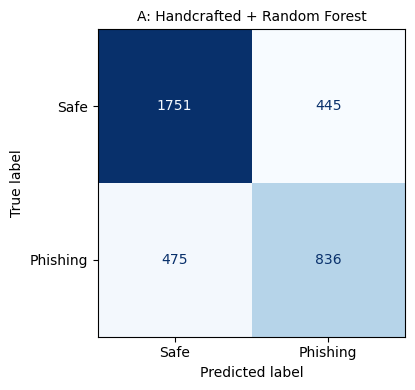

In [19]:
from sklearn.ensemble import RandomForestClassifier

NAME_A = "A: Handcrafted + Random Forest"
model_a = RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1)
metrics_a, pred_a = evaluate(NAME_A, model_a, X_train_feat, X_test_feat, "model_a")

### 3.4 Model B: TF-IDF + Logistic Regression

TF-IDF turns each email into word scores: a word scores high if it is frequent in that email but rare across all emails. Logistic Regression then learns a weight per word or word pair, positive for phishing and negative for safe.

B: TF-IDF + Logistic Regression
              precision    recall  f1-score   support

        Safe      0.982     0.989     0.985      2196
    Phishing      0.981     0.969     0.975      1311

    accuracy                          0.982      3507
   macro avg      0.982     0.979     0.980      3507
weighted avg      0.982     0.982     0.982      3507

5-fold CV F1 (phishing): 0.971 ± 0.003


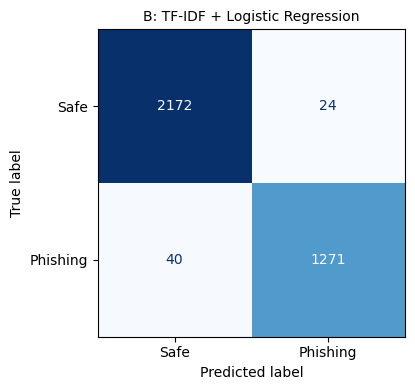

In [20]:
from sklearn.feature_extraction.text import TfidfVectorizer, ENGLISH_STOP_WORDS
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

def make_text_model(stop_words="english", token_pattern=r"(?u)\b\w\w+\b"):
    # Pipeline = TF-IDF then Logistic Regression, so .fit() learns the vocabulary from training data only
    return Pipeline([
        ("tfidf", TfidfVectorizer(
            ngram_range=(1, 2),          # single words and two-word phrases
            stop_words=stop_words,       # drop common words like "the" and "and"
            token_pattern=token_pattern, # what counts as a word (default: 2+ letters/digits)
            max_features=50_000,         # keep the 50,000 most frequent terms
            min_df=2,                    # ignore terms that appear in only one email
        )),
        ("clf", LogisticRegression(max_iter=1000)),
    ])

NAME_B = "B: TF-IDF + Logistic Regression"
model_b = make_text_model()
metrics_b, pred_b = evaluate(NAME_B, model_b, X_train_text, X_test_text, "model_b")

### 3.5 What did Model B learn? Checking for corpus artifacts

The Safe emails come mostly from the Enron corpus and a few mailing lists, while the phishing emails come from spam collections gathered in other years. If the top terms are source fingerprints (company names, people, years, list footers) rather than phishing language, the score is partly measuring *which dataset an email came from*.

In [21]:
def top_terms(pipeline, n=20):
    # Each term's learned weight: positive pushes toward phishing, negative toward safe
    terms = pipeline.named_steps["tfidf"].get_feature_names_out()
    weights = pipeline.named_steps["clf"].coef_[0]
    order = np.argsort(weights)
    phishing = pd.DataFrame({"term": terms[order[::-1][:n]], "weight": weights[order[::-1][:n]]})
    safe = pd.DataFrame({"term": terms[order[:n]], "weight": weights[order[:n]]})
    return phishing, safe

top_phish_b, top_safe_b = top_terms(model_b)
pd.concat([top_phish_b.add_prefix("phishing_"), top_safe_b.add_prefix("safe_")], axis=1).round(2)

,phishing_term,phishing_weight,safe_term,safe_weight
0,click,4.93,enron,-7.24
1,free,4.34,language,-4.49
2,money,3.91,thanks,-4.32
3,remove,3.61,2002,-4.31
4,email,3.56,wrote,-4.06
5,2005,3.45,university,-4.03
6,2004,3.00,2001,-3.53
7,online,2.91,linguistics,-3.49
8,life,2.91,attached,-3.42
9,save,2.89,vince,-3.40


In [22]:
# Evidence that some tokens are source fingerprints: how many emails of each class contain them
markers = ["enron", "ect", "hou", "vince", "kaminski", "linguist", "spamassassin", "mailman", "paliourg"]
lower_text = df["Email Text"].str.lower()
pd.DataFrame({m: lower_text.str.contains(rf"\b{m}\b").groupby(df["Email Type"]).sum() for m in markers}).T

Email Type,Phishing Email,Safe Email
enron,1,2239
ect,6,972
hou,9,895
vince,11,797
kaminski,0,559
linguist,2,280
spamassassin,169,515
mailman,194,1655
paliourg,122,0


In [23]:
# Tokens that identify the SOURCE of an email rather than its content, picked from the
# top-weighted terms above and further down the list:
ARTIFACT_TOKENS = {
    # Enron corpus: company, internal mail codes, location
    "enron", "ect", "hou", "hpl", "houston",
    # People who appear constantly in the Safe sources
    "vince", "kaminski", "louise", "sally", "daren", "kevin", "dave", "david", "mark", "john",
    # Mailing-list names, footers and archive sites
    "spamassassin", "sightings", "razor", "exmh", "xent", "newsisfree", "mailman", "listinfo", "fork", "cnet", "url",
    # Spam-corpus researcher name and text-encoding leftovers on the Phishing side
    "paliourg", "utf",
}

def is_artifact(term):
    # A term is an artifact if any word in it is a listed token or a pure number (years, phone codes, dates)
    return any(word in ARTIFACT_TOKENS or word.isdigit() for word in term.split())

for label, table in [("phishing", top_phish_b), ("safe", top_safe_b)]:
    flagged = table[table["term"].apply(is_artifact)]["term"].tolist()
    print(f"Top-20 {label} terms that are artifacts: {len(flagged)} -> {flagged}")

Top-20 phishing terms that are artifacts: 3 -> ['2005', '2004', 'spamassassin sightings']
Top-20 safe terms that are artifacts: 9 -> ['enron', '2002', '2001', 'vince', '2000', 'url', 'louise', 'url http', '713']


### 3.6 Model B rerun with artifacts removed

Retrain Model B once with the artifact tokens added to the stop words, and with numbers excluded from the vocabulary (a word must be 2+ letters). If the score barely moves, the model was mostly learning real content; if it drops a lot, the original score was inflated by source fingerprints.

B2: TF-IDF + LR, artifacts removed
              precision    recall  f1-score   support

        Safe      0.970     0.989     0.979      2196
    Phishing      0.980     0.950     0.965      1311

    accuracy                          0.974      3507
   macro avg      0.975     0.969     0.972      3507
weighted avg      0.974     0.974     0.974      3507

5-fold CV F1 (phishing): 0.959 ± 0.002


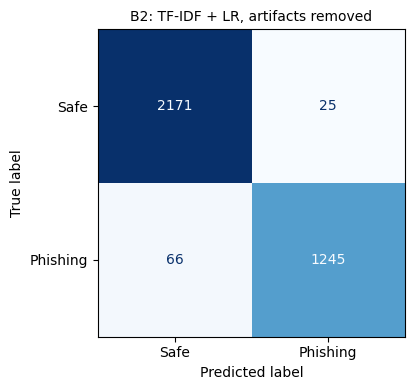

In [24]:
NAME_B2 = "B2: TF-IDF + LR, artifacts removed"
artifact_stop_words = list(ENGLISH_STOP_WORDS.union(ARTIFACT_TOKENS))
model_b2 = make_text_model(stop_words=artifact_stop_words, token_pattern=r"(?u)\b[a-zA-Z]{2,}\b")
metrics_b2, pred_b2 = evaluate(NAME_B2, model_b2, X_train_text, X_test_text, "model_b2")

In [25]:
top_phish_b2, top_safe_b2 = top_terms(model_b2)
pd.concat([top_phish_b2.add_prefix("phishing_"), top_safe_b2.add_prefix("safe_")], axis=1).round(2)

,phishing_term,phishing_weight,safe_term,safe_weight
0,click,4.49,wrote,-5.02
1,free,4.48,thanks,-4.75
2,money,4.17,language,-4.28
3,remove,3.90,date,-4.01
4,email,3.44,university,-3.97
5,save,3.22,attached,-3.84
6,online,3.10,pm,-3.68
7,life,3.08,com click,-3.51
8,site,2.94,edu,-3.45
9,software,2.84,click date,-3.43


### 3.7 Side-by-side comparison

All three models, scored on the same test emails. CV F1 shows how stable each score is across five different slices of the training data.

In [26]:
comparison = pd.DataFrame([metrics_a, metrics_b, metrics_b2]).set_index("model")
comparison.round(3)

,precision,recall,f1,accuracy,cv_f1_mean,cv_f1_std,true_negatives,false_positives,false_negatives,true_positives
model,,,,,,,,,,
A: Handcrafted + Random Forest,0.653,0.638,0.645,0.738,0.633,0.022,1751,445,475,836
B: TF-IDF + Logistic Regression,0.981,0.969,0.975,0.982,0.971,0.003,2172,24,40,1271
"B2: TF-IDF + LR, artifacts removed",0.980,0.950,0.965,0.974,0.959,0.002,2171,25,66,1245


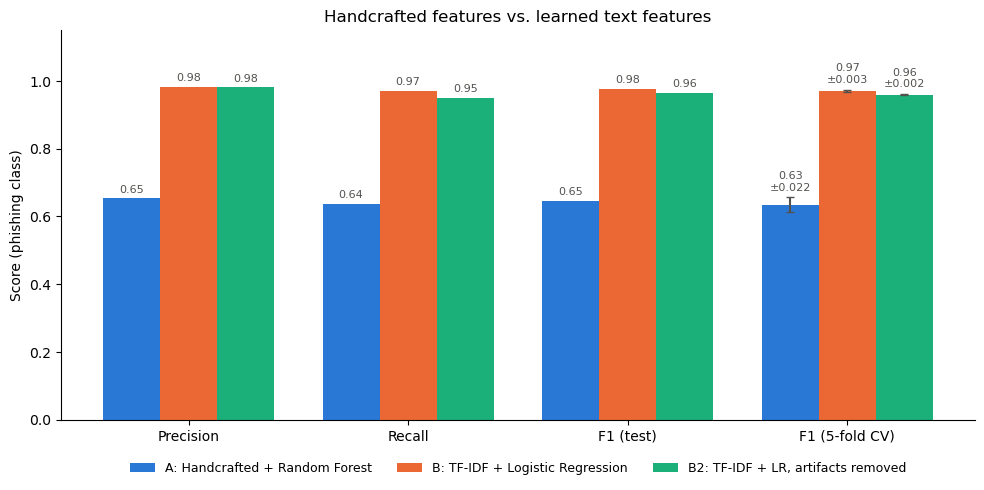

In [27]:
# Grouped bars: one group per metric, one bar per model; CV F1 bars carry ±1 std error bars
MODEL_COLORS = ["#2a78d6", "#eb6834", "#1baf7a"]
metric_cols = ["precision", "recall", "f1", "cv_f1_mean"]
metric_labels = ["Precision", "Recall", "F1 (test)", "F1 (5-fold CV)"]

x = np.arange(len(metric_cols))
width = 0.26
fig, ax = plt.subplots(figsize=(10, 5))
for i, (model_name, row) in enumerate(comparison.iterrows()):
    positions = x + (i - 1) * width
    bars = ax.bar(positions, row[metric_cols], width, label=model_name, color=MODEL_COLORS[i])
    # Error bar only on the CV bar (the test-set scores are single numbers with no spread)
    ax.errorbar(positions[-1], row["cv_f1_mean"], yerr=row["cv_f1_std"], color="#52514e", capsize=3)
    # Value labels: test-set bars get a plain label; the CV bar's label sits above its error bar
    ax.bar_label(bars, labels=[f"{v:.2f}" for v in row[metric_cols[:-1]]] + [""], padding=3, fontsize=8, color="#52514e")
    ax.text(positions[-1], row["cv_f1_mean"] + row["cv_f1_std"] + 0.015, f"{row['cv_f1_mean']:.2f}\n±{row['cv_f1_std']:.3f}",
            ha="center", va="bottom", fontsize=8, color="#52514e")

ax.set_xticks(x)
ax.set_xticklabels(metric_labels)
ax.set_ylim(0, 1.15)
ax.set_ylabel("Score (phishing class)")
ax.set_title("Handcrafted features vs. learned text features")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False, loc="upper center", bbox_to_anchor=(0.5, -0.08), ncol=3, fontsize=9)
fig.tight_layout()
fig.savefig("../dashboard/model_comparison.png", dpi=150, facecolor="white")
plt.show()

### 3.8 Headline: evasive phishing in the test set

"Evasive" phishing has no urgency phrases, no links and no IP links: none of the classic red flags. What share of test-set phishing is evasive, and how many of these emails does each model catch?

In [28]:
# Evasive = phishing with zero urgency phrases, zero links and no IP link (same definition as SQL query 3)
test = df.loc[test_idx]
is_evasive = ((test["label"] == 1) & (test["urgency_score"] == 0)
              & (test["url_count"] == 0) & (test["has_ip_url"] == 0)).values

n_evasive = is_evasive.sum()
n_phish_test = int(y_test.sum())
print(f"Evasive phishing in test set: {n_evasive} of {n_phish_test} phishing emails ({n_evasive / n_phish_test:.1%})")

evasive_results = pd.DataFrame([
    {"model": name,
     "evasive_caught": int(pred[is_evasive].sum()),
     "evasive_total": int(n_evasive),
     "evasive_recall": pred[is_evasive].mean(),
     "overall_phishing_recall": recall_score(y_test, pred)}
    for name, pred in [(NAME_A, pred_a), (NAME_B, pred_b), (NAME_B2, pred_b2)]
])
evasive_results.round(3)

Evasive phishing in test set: 574 of 1311 phishing emails (43.8%)


,model,evasive_caught,evasive_total,evasive_recall,overall_phishing_recall
0,A: Handcrafted + Random Forest,304,574,0.530,0.638
1,B: TF-IDF + Logistic Regression,549,574,0.956,0.969
2,"B2: TF-IDF + LR, artifacts removed",536,574,0.934,0.950


### 3.9 Model A feature importances

Which of the six handcrafted features does the Random Forest rely on? The built-in importance can overrate features with many distinct values (like email length), so permutation importance is shown too: it shuffles one feature at a time on the test set and measures how much F1 drops.

In [29]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(model_a, X_test_feat, y_test, scoring="f1", n_repeats=10, random_state=42, n_jobs=-1)

importances = pd.DataFrame({
    "feature": FEATURES,
    "impurity_importance": model_a.feature_importances_,
    "permutation_importance_mean": perm.importances_mean,
    "permutation_importance_std": perm.importances_std,
}).sort_values("permutation_importance_mean", ascending=False).reset_index(drop=True)
importances.round(4)

,feature,impurity_importance,permutation_importance_mean,permutation_importance_std
0,exclamation_count,0.2236,0.1785,0.0059
1,email_length,0.6321,0.1031,0.0124
2,urgency_score,0.0667,0.0557,0.0056
3,url_count,0.0483,0.0397,0.0056
4,bait_score,0.0216,0.0135,0.0025
5,has_ip_url,0.0077,0.0066,0.0015


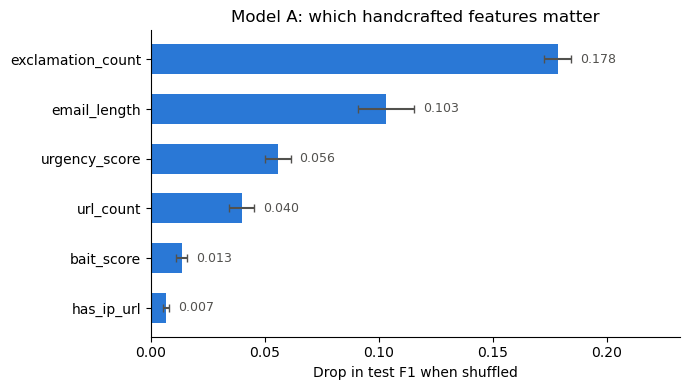

In [30]:
# Horizontal bars, sorted, for permutation importance (drop in test F1 when the feature is shuffled)
plot_data = importances.sort_values("permutation_importance_mean")
fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.barh(plot_data["feature"], plot_data["permutation_importance_mean"], color="#2a78d6", height=0.6,
               xerr=plot_data["permutation_importance_std"], error_kw={"ecolor": "#52514e", "capsize": 3})
ax.bar_label(bars, labels=[f"{v:.3f}" for v in plot_data["permutation_importance_mean"]], padding=6, fontsize=9, color="#52514e")
ax.set_xlabel("Drop in test F1 when shuffled")
ax.set_title("Model A: which handcrafted features matter")
ax.spines[["top", "right"]].set_visible(False)
ax.set_xlim(0, plot_data["permutation_importance_mean"].max() * 1.3)
fig.tight_layout()
fig.savefig("../dashboard/feature_importance.png", dpi=150, facecolor="white")
plt.show()